# 2. Performance Gap

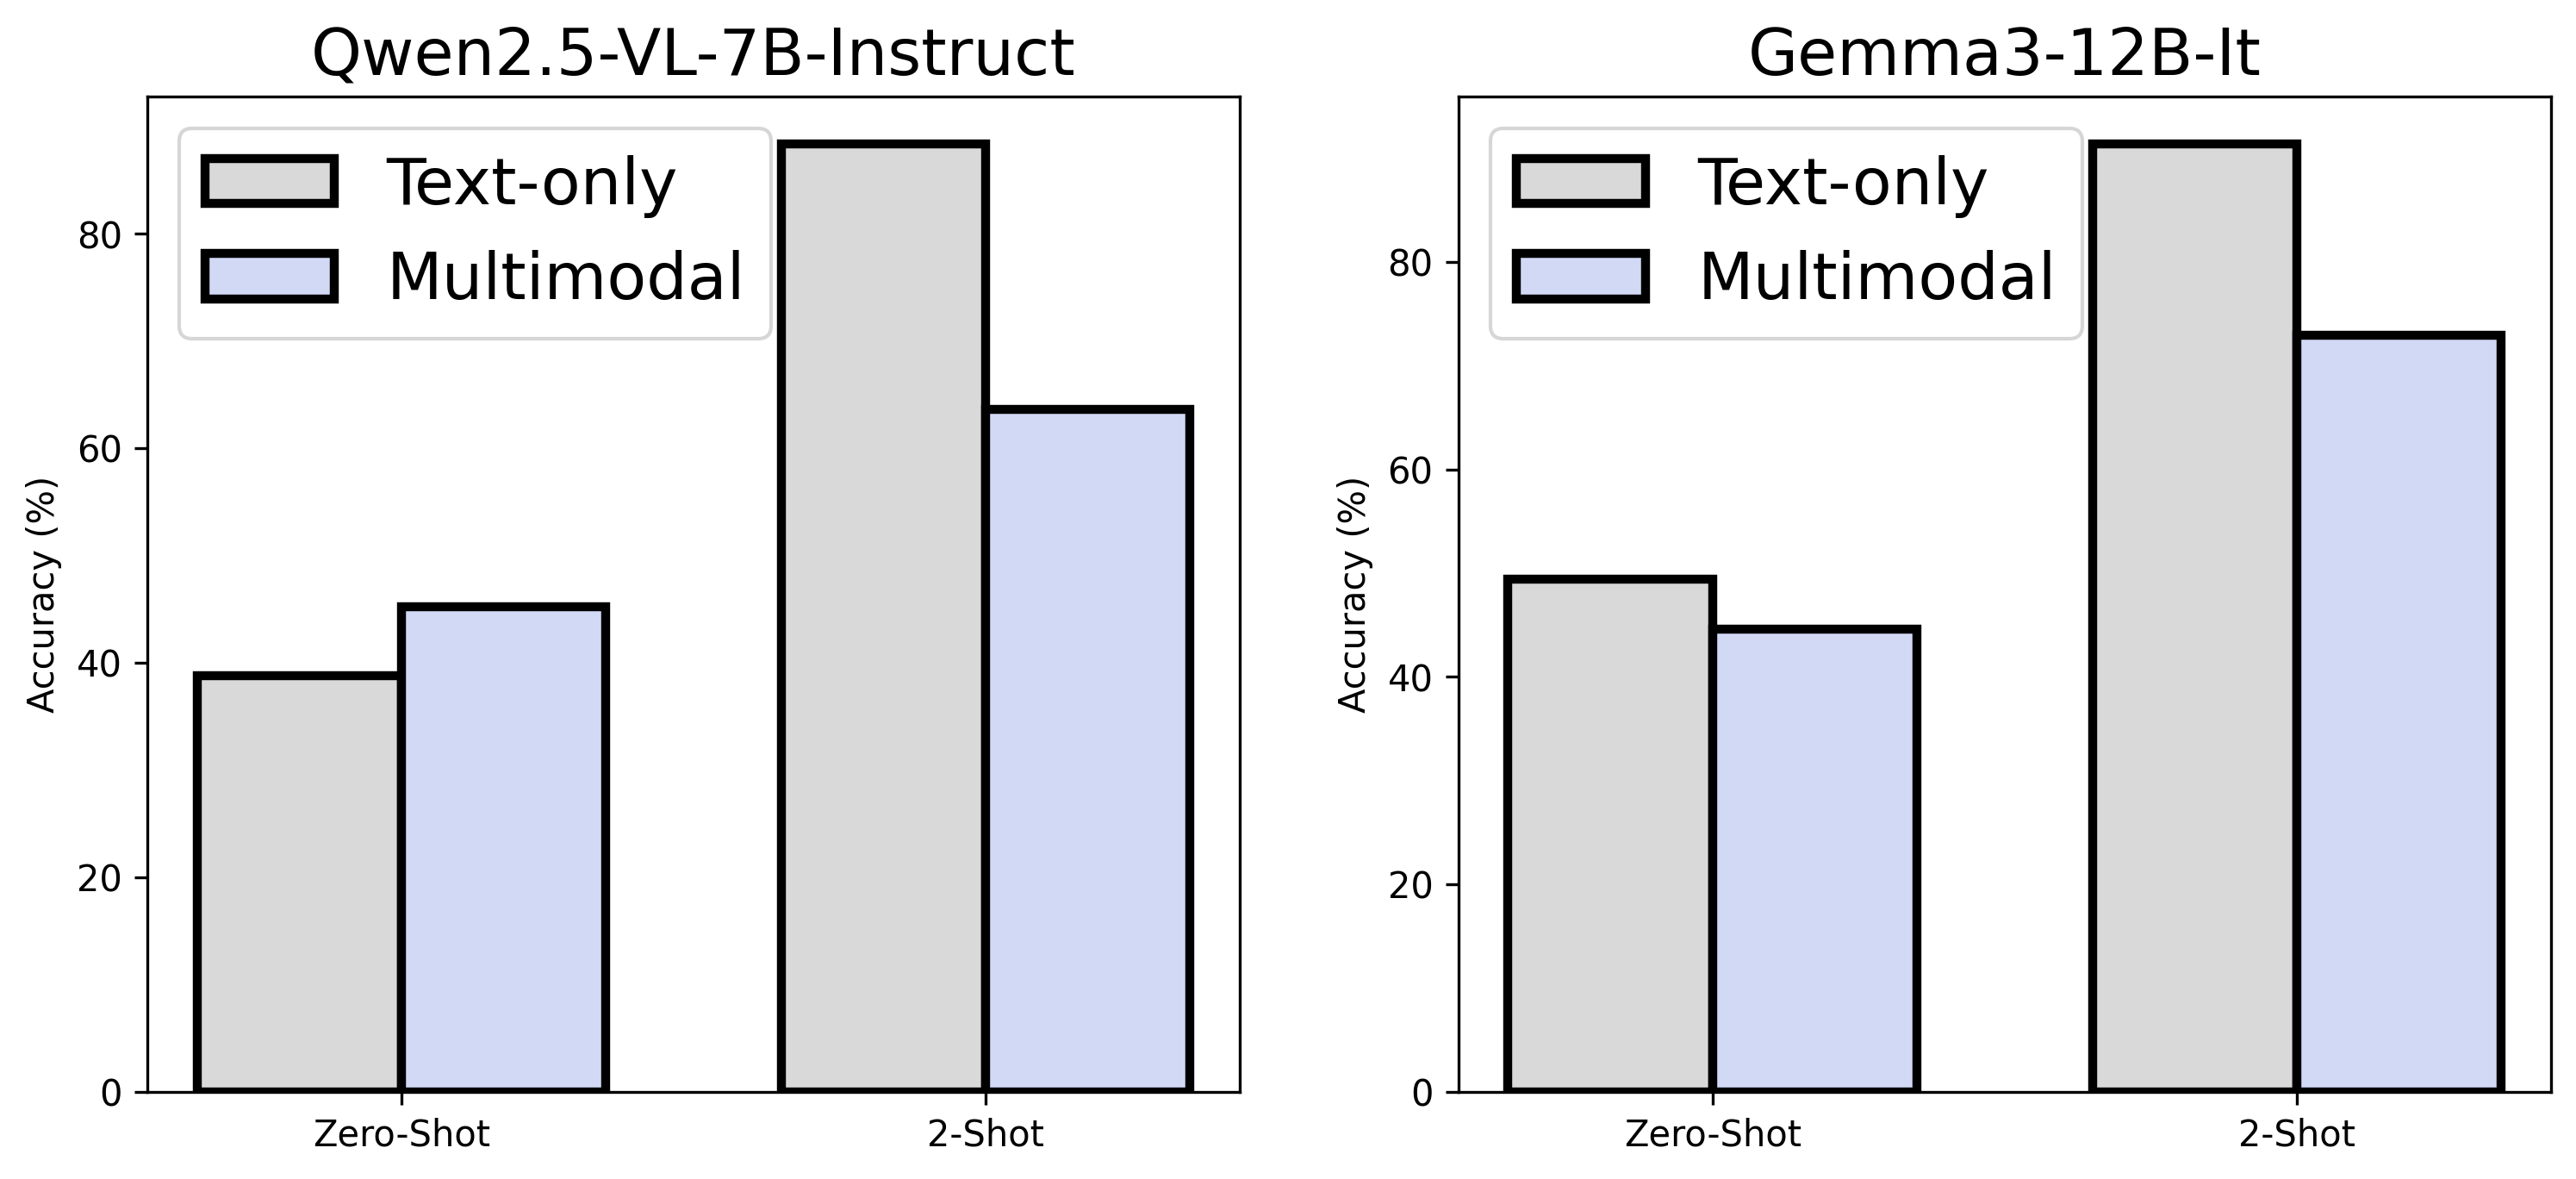

In [1]:
import matplotlib.pyplot as plt
import numpy as np

########
text_color = "#D9D9D9"
multi_color = "#D1D9F5"

labels = ["Zero-Shot", "2-Shot"]
text_q25 = [38.8, 88.4]
multi_q25 = [45.2, 63.6]

text_gemma = [49.40, 91.4] #[0., 0.66667]
multi_gemma = [44.6, 72.93] # [0.840666667, 0.576666667]

x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(12,5), dpi=300)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 14

# Left
axs[0].bar(x - width/2, text_q25, width, color=text_color, edgecolor="black", linewidth=2.5, label="Text-only")
axs[0].bar(x + width/2, multi_q25, width, color=multi_color, edgecolor="black",linewidth=2.5,  label="Multimodal")
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].set_ylabel("Accuracy (%)")
axs[0].set_title("Qwen2.5-VL-7B-Instruct")
axs[0].legend()

# Right
axs[1].bar(x - width/2, text_gemma, width, color=text_color, edgecolor="black", linewidth=2.5, label="Text-only")
axs[1].bar(x + width/2, multi_gemma, width, color=multi_color, edgecolor="black", linewidth=2.5,  label="Multimodal")
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels)
axs[1].set_ylabel("Accuracy (%)")
axs[1].set_title("Gemma3-12B-It")
axs[1].legend()

# plt.show()


# 3. False Case Analysis

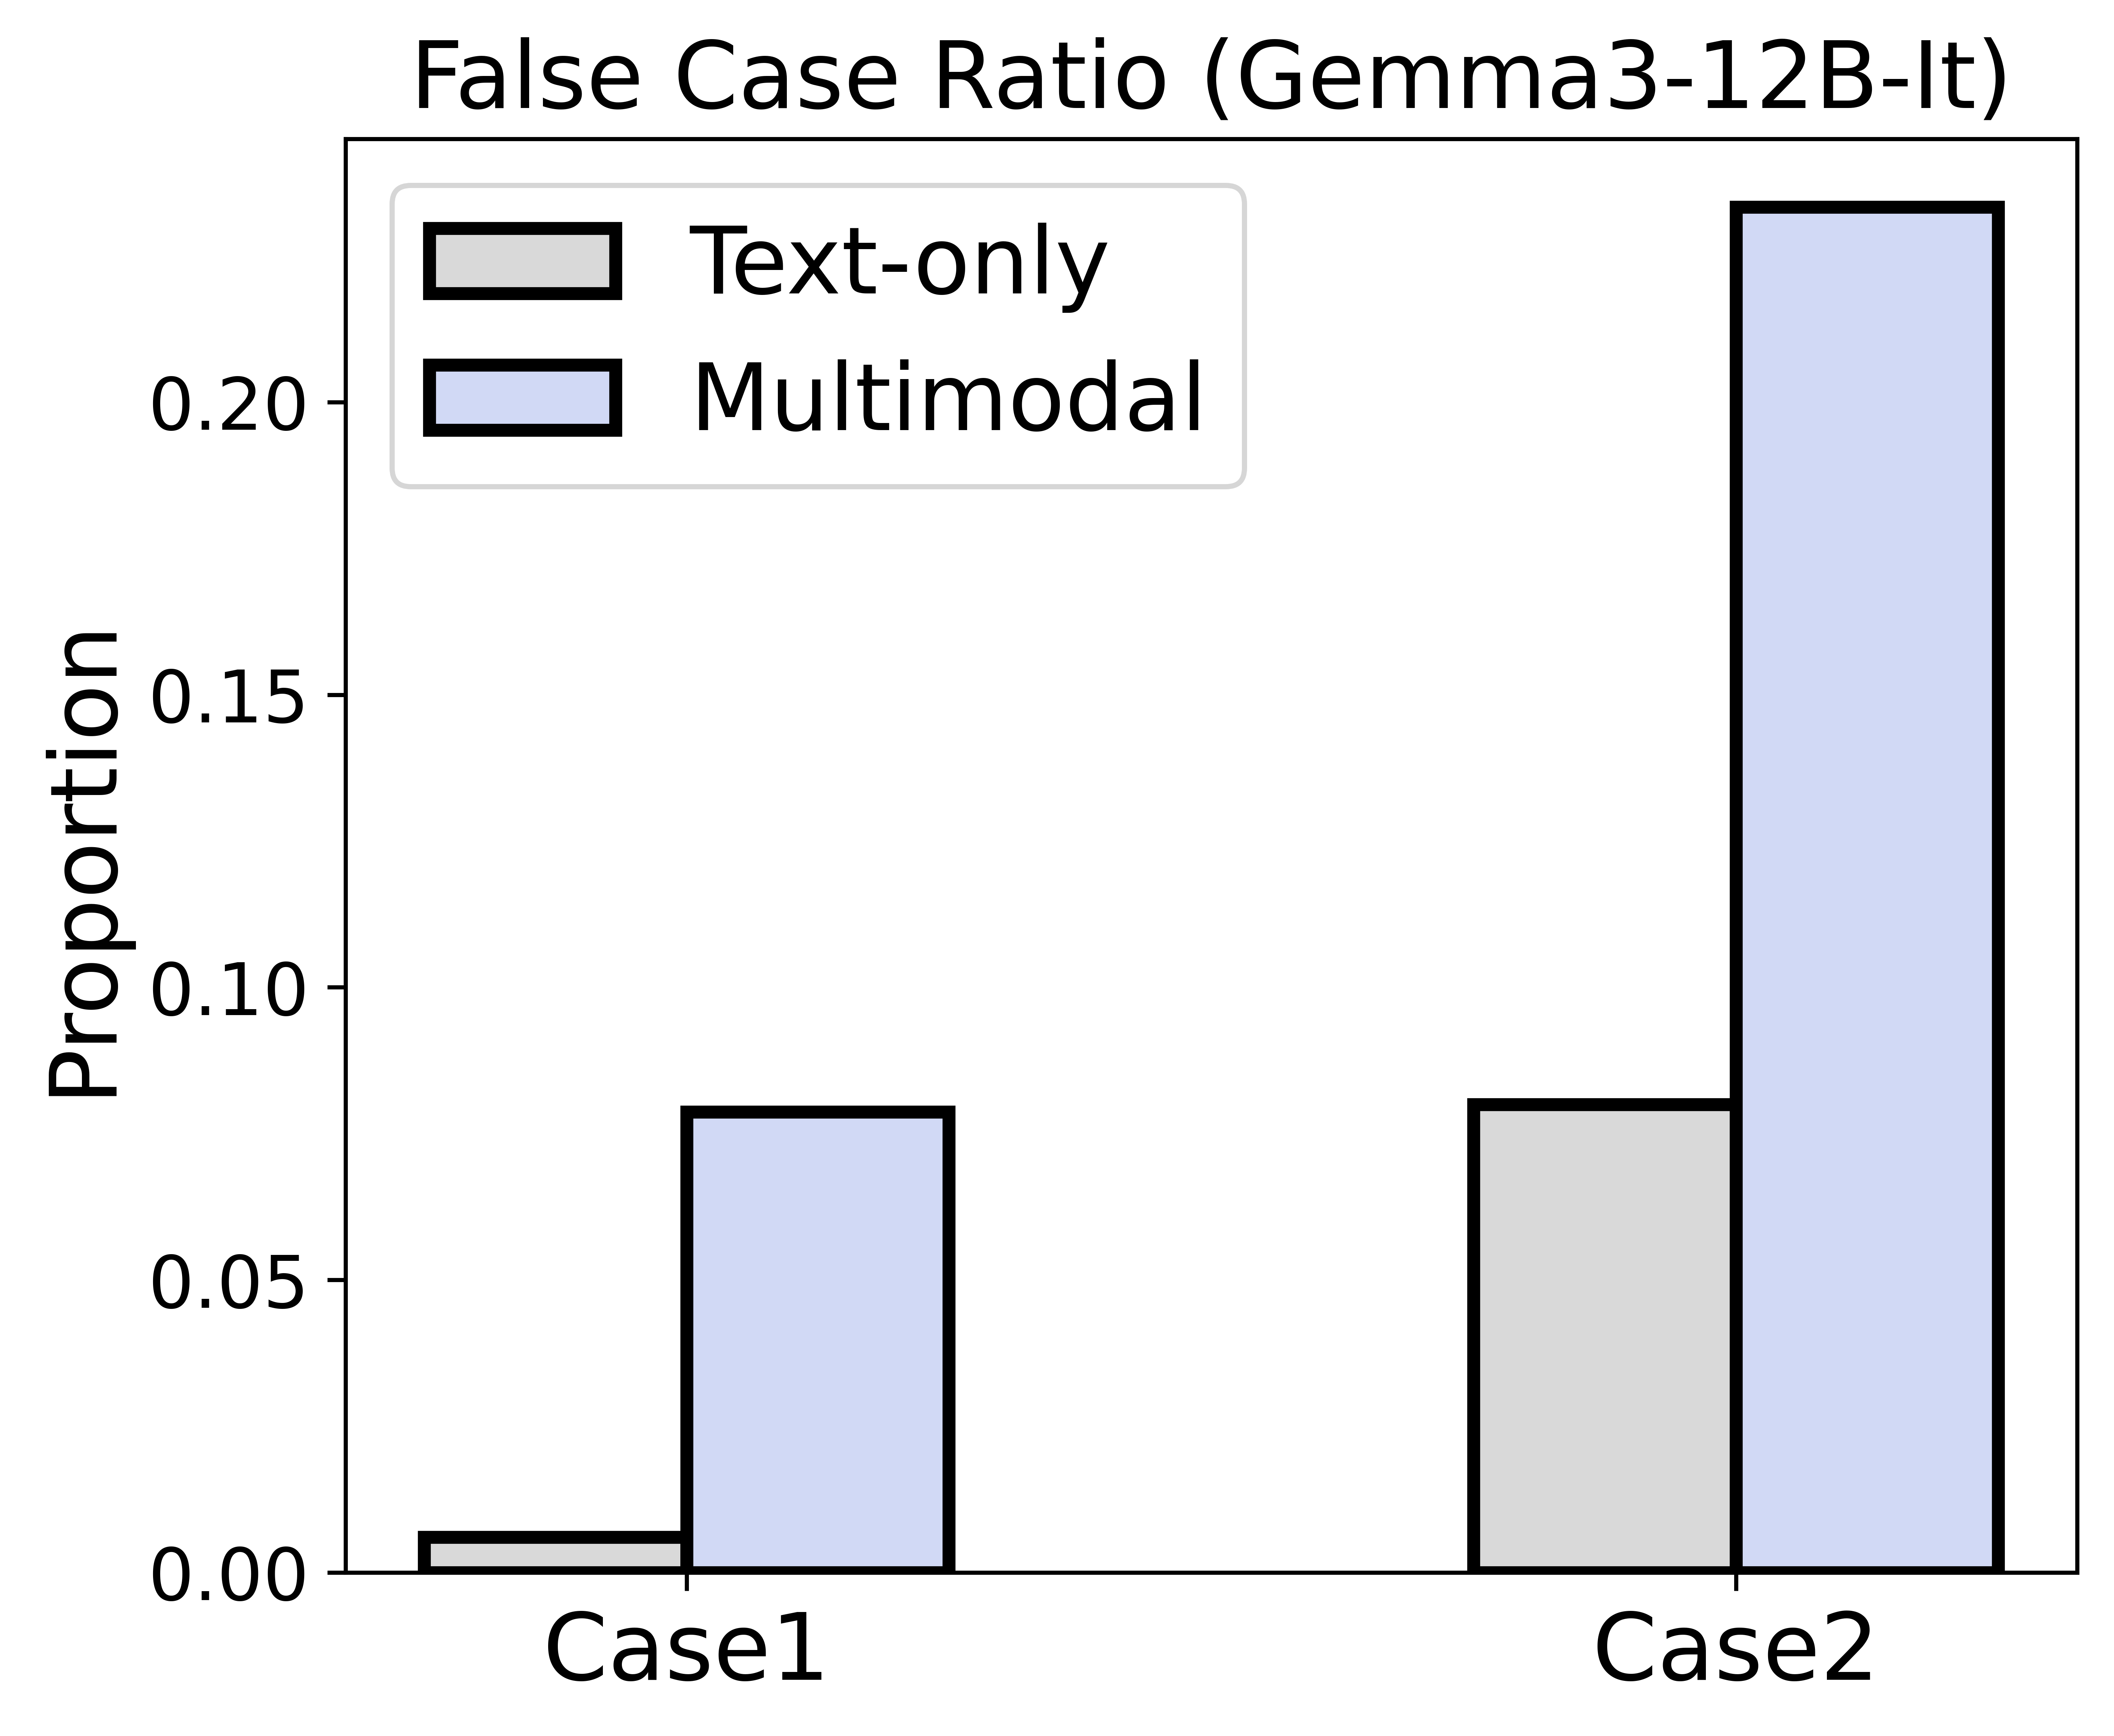

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# averaged results you gave
labels = ["Case1", "Case2"]
correct_type_but_false = [0.0787, 0.233333333]
false_type = [0.006,0.08]

x = np.arange(len(labels))
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(6, 5), dpi=1000)


color_correct = "#D9D9D9"
color_ctbf ="#D9D9D9"
color_false =  "#D1D9F5"


# three bars per group
# ax.bar(x - width, correct, width, edgecolor="black", linewidth=2.5, color=color_correct)  # ,label="Correct")
ax.bar(x -0.5 * width, false_type, width, edgecolor="black", linewidth=2.5, color=color_ctbf , label="Text-only")   # , label="False Task Recognition")
ax.bar(x +0.5 * width, correct_type_but_false, width, edgecolor="black", linewidth=2.5,color=color_false, label="Multimodal")  # , label="Correct Task Recognition but False answer")

# fig, ax = plt.subplots(figsize=(5, 3), dpi=1000)

# color_correct = "green"
# color_ctbf = "orange"
# color_false = "red"

# # three bars per group
# ax.bar(x - width, correct, width, color=color_correct,label="Correct")
# ax.bar(x, correct_type_but_false, width,color=color_ctbf, label="Correct Task Recognition but False answer")
# ax.bar(x + width, false_type, width, color=color_false, label="False Task Recognition")

ax.set_ylabel("Proportion")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("False Case Ratio (Gemma3-12B-It)")
ax.legend()

# plt.tight_layout()
# plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# averaged results you gave
labels = ["Case1", "Case2"]
correct = [0.840666667, 0.576666667]
correct_type_but_false = [0.078666667, 0.344666667] 
false_type = [0.045333333, 0.114]

x = np.arange(len(labels))
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(6, 5), dpi=1000)


color_correct = "#D9D9D9"
color_ctbf ="#D9D9D9"
color_false =  "#D1D9F5"


# three bars per group
# ax.bar(x - width, correct, width, edgecolor="black", linewidth=2.5, color=color_correct)  # ,label="Correct")
ax.bar(x -0.5 * width, false_type, width, edgecolor="black", linewidth=2.5, color=color_ctbf, label="Text-only")   # , label="False Task Recognition")
ax.bar(x +0.5 * width, correct_type_but_false, width, edgecolor="black", linewidth=2.5,color=color_false, label="Multimodal")  # , label="Correct Task Recognition but False answer")


ax.set_ylabel("Proportion")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("False Case Ratio (Qwen2-VL-7B)")
ax.legend()

plt.tight_layout()
plt.show()

# 4. Layerwise Label -> demo's text/image modality attention

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
d = torch.load("/nobackup2/yuwang/ICL_Circuit/Attn_curve_new/shape_ood/google_gemma-3-12b-it/label_to_demo_attn_curves.pt", weights_only=False)
all_img_curves = d["image_curves"]
all_txt_curves = d["text_curves"]


def plot_img_text_attn(
    all_img_curves,
    all_txt_curves,
    title=None,
    save_path=None,
    figsize=(5, 5),
    ylim=(0, 1),
    show_mean_lines=True,
):
    """
    all_img_curves: list[np.ndarray(L,)]  每个样本一条 image curve
    all_txt_curves: list[np.ndarray(L,)]  每个样本一条 text curve
    """

    # 基本排版字体
    plt.rcParams.update({
        "font.size": 18,        # 坐标轴、刻度、legend 基础字体
        "axes.titlesize": 18,   # 标题
        "axes.labelsize": 16,   # x/y label
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 15,
    })

    # 转成数组 (N, L)
    img_arr = np.stack(all_img_curves, axis=0)
    txt_arr = np.stack(all_txt_curves, axis=0)

    # 维度检查
    assert img_arr.shape == txt_arr.shape, \
        f"img_arr.shape {img_arr.shape} != txt_arr.shape {txt_arr.shape}"

    L = img_arr.shape[1]
    layers = np.arange(L)

    # 均值和方差
    img_mean = img_arr.mean(axis=0)
    img_std = img_arr.std(axis=0)

    txt_mean = txt_arr.mean(axis=0)
    txt_std = txt_arr.std(axis=0)

    # 使用 fig, ax 方式，确保 figsize 生效
    fig, ax = plt.subplots(figsize=figsize)

    # 文本曲线 



    ax.errorbar(
        layers,
        txt_mean,
        yerr=txt_std,
        color = "#B8B7B7",
        fmt="o-",
        markersize=5,
        capsize=3,
         linewidth=2,
        label="Text Token",
    )

    # 图像曲线 "#D9D9D9"
    ax.errorbar(
        layers,
        img_mean,
        yerr=img_std,
        color = "#94ABFF",
        fmt="s-",
        markersize=5,
        capsize=3,
        linewidth=2,
        label="Image Token",
    )

    # 全局均值虚线
    if show_mean_lines:
        ax.axhline(txt_mean.mean(), linestyle="--") #, alpha=0.5
        ax.axhline(img_mean.mean(), linestyle="--") #, alpha=0.5

    ax.set_xlabel("Layer index")
    ax.set_ylabel("Relative attention per token")

    if title is not None:
        ax.set_title(title)

    ax.set_xlim(-0.5, L - 0.5)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=800)
        plt.close(fig)
    else:
        plt.show()


plot_img_text_attn(all_img_curves, all_txt_curves, 
                            title="Cached curves",
                            save_path="cached_plot.png")


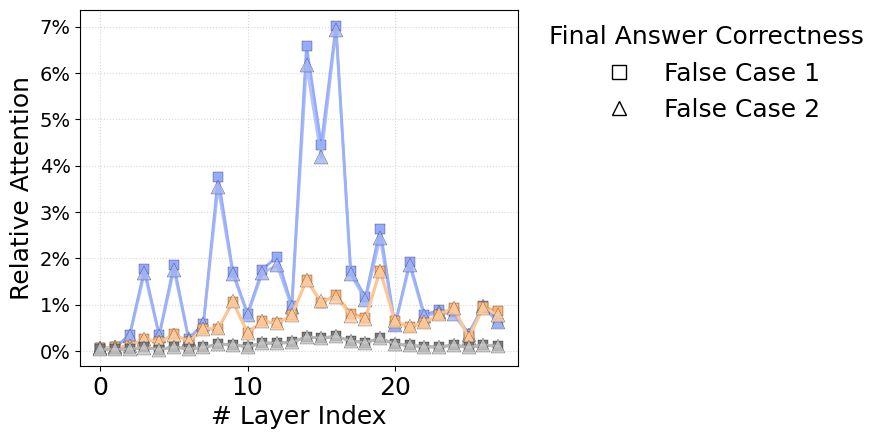

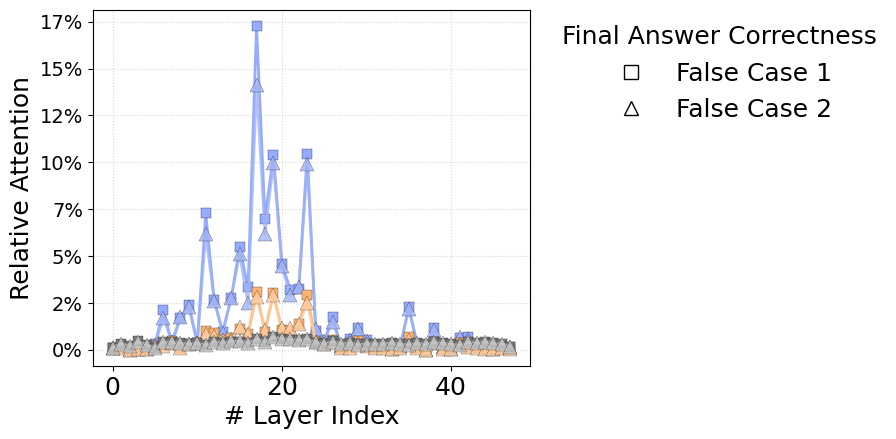

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"]='1,2'

def load_json_curve(path):
    with open(path, "r") as f:
        data = json.load(f)

    layers = np.array([d["layer"] for d in data])
    evidence = np.array([d["correct_avg"] for d in data])
    false_evidence = np.array([d["false_avg"] for d in data])
    nonevidence = np.array([d["other_avg"] for d in data])
    return layers, evidence, false_evidence, nonevidence


def plot_visual_style(correct_json, false_json, title=None, save=None):

    layers, ev_true, fe_true, nonev_true = load_json_curve(correct_json)
    _, ev_false, fe_false, nonev_false = load_json_curve(false_json)

    # 百分比
    ev_true *= 100
    ev_false *= 100
    fe_true *= 100
    fe_false *= 100
    nonev_true *= 100
    nonev_false *= 100

    fig, ax = plt.subplots(figsize=(5,4))

    # ==========================
    # Evidence (蓝色)
    # ==========================

    # False Evidence (蓝)
    ax.plot(
        layers,
        ev_false,
        color="#94ABFF",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True Evidence (浅蓝)
    ax.plot(
        layers,
        ev_true,
        color="#A0B3F6",
        alpha=0.8,
        marker="^",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # ==========================
    # False-Evidence (橙色)
    # ==========================

    # False FE (深橙)
    ax.plot(
        layers,
        fe_false,
        color="#FDB372",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True FE (浅橙)
    ax.plot(
        layers,
        fe_true,
        color="#FDCB9F",
        alpha=0.8,
        marker="^",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # ==========================
    # Non-Evidence (灰色)
    # ==========================

    # False Non-Evidence (深灰)
    ax.plot(
        layers,
        nonev_false,
        color="#7A7A7A",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True Non-Evidence (浅灰)
    ax.plot(
        layers,
        nonev_true,
        color="#C7C7C7",
        alpha=0.8,
        marker="^",
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # y 轴百分比格式
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y)}%"))

    ax.set_xlabel("# Layer Index")
    ax.set_ylabel("Relative Attention")
    ax.grid(True, linestyle=":", alpha=0.5)

    # =============== Legend 1：Token Type（颜色） ============
    legend_token = ax.legend(
        handles=[
            plt.Line2D([0],[0], color="#94ABFF", linewidth=2),
            plt.Line2D([0],[0], color="#FFBC93", linewidth=2),
            plt.Line2D([0],[0], color="#7A7A7A", linewidth=2),
        ],
        labels=["Evidence", "False-Evidence", "Non-Evidence"],
        title="Image Token Type",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.28),
        frameon=False,
        ncol=3,
    )
    ax.add_artist(legend_token)

    # =============== Legend 2：Correctness（marker） ============
    ax.legend(
        handles=[
            plt.Line2D([0],[0], marker="s", markersize=10,
                       markerfacecolor="white", markeredgecolor="black",
                       linestyle="none"),
            plt.Line2D([0],[0], marker="^", markersize=10,
                       markerfacecolor="white", markeredgecolor="black",
                       linestyle="none"),
        ],
        labels=["False Case 1", "False Case 2"],
        title="Final Answer Correctness",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.02),
        frameon=False
    )

    # 给右边留白
    fig.subplots_adjust(top=1, right=1)

    if save:
        fig.savefig(save, dpi=1000, bbox_inches="tight")

    plt.show()

plot_visual_style(
    "/nobackup2/yuwang/ICL_Circuit/False_case1_Qwen_Qwen2.5-VL-7B-Instruct_total_attention_ratios_per_layer.json",
    "/nobackup2/yuwang/ICL_Circuit/False_case2_Qwen_Qwen2.5-VL-7B-Instruct_total_attention_ratios_per_layer.json",
    title="Qwen2.5-VL-7B-Instruct",
    save="qwen25_total_avg.png",
)

plot_visual_style(
    "/nobackup2/yuwang/ICL_Circuit/False_case1_google_gemma-3-12b-it_total_attention_ratios_per_layer.json",
    "/nobackup2/yuwang/ICL_Circuit/False_case2_google_gemma-3-12b-it_total_attention_ratios_per_layer.json",
    title="google_gemma-3-12b-it",
    save="google_gemma-3_total_avg.png",
)


# 5. Evidence-related attention

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def load_json_curve(path):
    with open(path, "r") as f:
        data = json.load(f)

    layers = np.array([d["layer"] for d in data])
    evidence = np.array([d["correct_avg"] for d in data])
    false_evidence = np.array([d["false_avg"] for d in data])
    nonevidence = np.array([d["other_avg"] for d in data])
    return layers, evidence, false_evidence, nonevidence


def plot_visual_style(correct_json, false_json, title=None, save=None):

    layers, ev_true, fe_true, nonev_true = load_json_curve(correct_json)
    _, ev_false, fe_false, nonev_false = load_json_curve(false_json)

    # 百分比
    ev_true *= 100
    ev_false *= 100
    fe_true *= 100
    fe_false *= 100
    nonev_true *= 100
    nonev_false *= 100

    fig, ax = plt.subplots(figsize=(5,4))

    # ==========================
    # Evidence (蓝色)
    # ==========================

    # False Evidence (蓝)
    ax.plot(
        layers,
        ev_false,
        color="#94ABFF",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True Evidence (浅蓝)
    ax.plot(
        layers,
        ev_true,
        color="#A0B3F6",
        alpha=0.5,
        marker=".",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # ==========================
    # False-Evidence (橙色)
    # ==========================

    # False FE (深橙)
    ax.plot(
        layers,
        fe_false,
        color="#FDB372",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True FE (浅橙)
    ax.plot(
        layers,
        fe_true,
        color="#FDCB9F",
        alpha=0.8,
        marker=".",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # ==========================
    # Non-Evidence (灰色)
    # ==========================

    # False Non-Evidence (深灰)
    ax.plot(
        layers,
        nonev_false,
        color="#7A7A7A",
        marker="s",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # True Non-Evidence (浅灰)
    ax.plot(
        layers,
        nonev_true,
        color="#C7C7C7",
        alpha=0.8,
        marker=".",
        markersize=7,
        markeredgecolor="black",
        markeredgewidth=0.2,
        linestyle="-",
        linewidth=2,
    )

    # y 轴百分比格式
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y)}%"))

    ax.set_xlabel("# Layer Index")
    ax.set_ylabel("Relative Attention")
    ax.grid(True, linestyle=":", alpha=0.5)

    # =============== Legend 1：Token Type（颜色） ============
    legend_token = ax.legend(
        handles=[
            plt.Line2D([0],[0], color="#94ABFF", linewidth=2),
            plt.Line2D([0],[0], color="#FFBC93", linewidth=2),
            plt.Line2D([0],[0], color="#7A7A7A", linewidth=2),
        ],
        labels=["Evidence", "False-Evidence", "Non-Evidence"],
        title="Image Token Type",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.28),
        frameon=False,
        ncol=3,
    )
    ax.add_artist(legend_token)

    # =============== Legend 2：Correctness（marker） ============
    ax.legend(
        handles=[
            plt.Line2D([0],[0], marker=".", markersize=10,
                       markerfacecolor="white", markeredgecolor="black",
                       linestyle="none"),
            plt.Line2D([0],[0], marker="s", markersize=7,
                       markerfacecolor="white", markeredgecolor="black",
                       linestyle="none"),
        ],
        labels=["True", "False"],
        title="Final Answer Correctness",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.02),
        frameon=False
    )

    # 给右边留白
    fig.subplots_adjust(top=0.78, right=0.80)

    if save:
        fig.savefig(save, dpi=1000, bbox_inches="tight")

    plt.show()

plot_visual_style(
    "/nobackup2/yuwang/ICL_Circuit/att_dis_on_correct_false/CORR_Qwen_Qwen2.5-VL-7B-Instruct_total_attention_ratios_per_layer.json",
    "/nobackup2/yuwang/ICL_Circuit/att_dis_on_correct_false/ERROR_Qwen_Qwen2.5-VL-7B-Instruct_total_attention_ratios_per_layer.json",
    title="Qwen2.5-VL-7B-Instruct",
    save="qwen25_evidence_non_evidence.png",
)

plot_visual_style(
    "/nobackup2/yuwang/ICL_Circuit/att_dis_on_correct_false/CORR_google_gemma-3-12b-it_total_attention_ratios_per_layer.json",
    "/nobackup2/yuwang/ICL_Circuit/att_dis_on_correct_false/ERROR_google_gemma-3-12b-it_total_attention_ratios_per_layer.json",
    title="google_gemma-3-12b-it",
    save="google_gemma-3-12b-it_evidence_non_evidence.png",
)




In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def load_json_curve(path):
    with open(path, "r") as f:
        data = json.load(f)
    return data

data = load_json_curve(
    "/nobackup2/yuwang/ICL_Circuit/fase_vs_correct_sample/COMPARE_[OOD]_Qwen_Qwen2.5-VL-7B-Instruct_last_tkn2demos_per.json"
)

# 原始 layer 编号
layers_id  = np.array([d["layer"] for d in data])
# 实际用于绘图的 x 位置（拉开一点）
layers_pos = layers_id * 2

corr = np.array([d["label_avg_correct"] for d in data])
err0 = np.array([d["label_avg_error"]   for d in data])

diff = abs(corr - err0)
err  = np.array([c - 2*d for (c, d) in zip(corr, diff)])
diff = corr - err

plt.rcParams["font.size"]       = 18
plt.rcParams["axes.titlesize"]  = 18
plt.rcParams["axes.labelsize"]  = 18
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

color_correct = "#8CA4FA"
color_false   = "#DFDFDF"

fig, axs = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, dpi=1000,
    gridspec_kw={"height_ratios": [2.4, 1]}
)

# 柱子加宽一点
width = 0.8


axs[0].bar(
    layers_pos + width/2,
    corr,
    width=width,
    color=color_correct,
    edgecolor="black",
    label="CORRECT Sample",
)
axs[0].bar(
    layers_pos - width/2,
    err,
    width=width,
    color=color_false,
    edgecolor="black",
    label="ERROR Sample",
)

axs[0].set_ylabel("Attention ratio")
axs[0].legend(loc="upper left")
axs[0].grid(alpha=0.3)
step = max(1, len(layers_id) // 8)

tick_pos   = layers_pos[::step]
tick_label = layers_id[::step]

axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_label)

# 下图
axs[1].axhline(0, color="black", linestyle="--", linewidth=1)
axs[1].plot(layers_pos, diff, color="black", linewidth=1.5)

axs[1].fill_between(layers_pos, 0, diff, where=diff >= 0,
                    color="#FEB062", alpha=0.25)
axs[1].fill_between(layers_pos, 0, diff, where=diff < 0,
                    color="#909090", alpha=0.25)

axs[1].set_xlabel("Layer ID")
axs[1].set_title("Attention Difference (Correct − Error)")
axs[1].grid(color="#D1DBFC")


# x 轴刻度显示原始 layer 编号
# axs[1].set_xticks(layers_pos)
# axs[1].set_xticklabels(layers_id
step = max(1, len(layers_id) // 8)

tick_pos   = layers_pos[::step]
tick_label = layers_id[::step]

axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_label)
axs[1].set_xticks(tick_pos)
axs[1].set_xticklabels(tick_label)

fig.tight_layout()
plt.savefig("qwen25_query_attn.png")


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def load_json_curve(path):
    with open(path, "r") as f:
        data = json.load(f)
    return data

data = load_json_curve(
    "/nobackup2/yuwang/ICL_Circuit/fase_vs_correct_sample/COMPARE_[OOD]_google_gemma-3-12b-it_last_tkn2demos_per.json"
)

# 原始 layer 编号
layers_id  = np.array([d["layer"] for d in data])
# 实际用于绘图的 x 位置（拉开一点）
layers_pos = layers_id * 2

corr = np.array([d["label_avg_correct"] for d in data])
err0 = np.array([d["label_avg_error"]   for d in data])

diff = abs(corr - err0)
err  = np.array([c - d for (c, d) in zip(corr, diff)])
diff = corr - err

plt.rcParams["font.size"]       = 18
plt.rcParams["axes.titlesize"]  = 18
plt.rcParams["axes.labelsize"]  = 18
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

color_correct = "#8CA4FA"
color_false   = "#DFDFDF"

fig, axs = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, dpi=1000,
    gridspec_kw={"height_ratios": [2.4, 1]}
)

# 柱子加宽一点
width = 0.8
axs[0].bar(
    layers_pos + width/2,
    corr,
    width=width,
    color=color_correct,
    edgecolor="black",
    label="CORRECT Sample",
)
axs[0].bar(
    layers_pos - width/2,
    err,
    width=width,
    color=color_false,
    edgecolor="black",
    label="ERROR Sample",
)

axs[0].set_ylabel("Attention ratio")
axs[0].legend(loc="upper left")
axs[0].grid(alpha=0.3)
step = max(1, len(layers_id) // 8)

tick_pos   = layers_pos[::step]
tick_label = layers_id[::step]

axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_label)

# 下图
axs[1].axhline(0, color="black", linestyle="--", linewidth=1)
axs[1].plot(layers_pos, diff, color="black", linewidth=1.5)

axs[1].fill_between(layers_pos, 0, diff, where=diff >= 0,
                    color="#FEB062", alpha=0.25)
axs[1].fill_between(layers_pos, 0, diff, where=diff < 0,
                    color="#909090", alpha=0.25)

axs[1].set_xlabel("Layer ID")
axs[1].set_title("Attention Difference (Correct − Error)")
axs[1].grid(color="#D1DBFC")


# x 轴刻度显示原始 layer 编号
# axs[1].set_xticks(layers_pos)
# axs[1].set_xticklabels(layers_id
step = max(1, len(layers_id) // 8)

tick_pos   = layers_pos[::step]
tick_label = layers_id[::step]

axs[0].set_xticks(tick_pos)
axs[0].set_xticklabels(tick_label)
axs[1].set_xticks(tick_pos)
axs[1].set_xticklabels(tick_label)

fig.tight_layout()
plt.savefig("gemma-3_query_attn.png")
